In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_orders = pd.read_csv("olist_orders_dataset.csv")
df_customers = pd.read_csv("olist_customers_dataset.csv")
df_items = pd.read_csv("olist_order_items_dataset.csv")

In [3]:
df_orders.shape

(99441, 8)

In [4]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [5]:
df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
df_orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [7]:
df_orders["order_purchase_timestamp"] = pd.to_datetime(df_orders["order_purchase_timestamp"], errors="coerce")

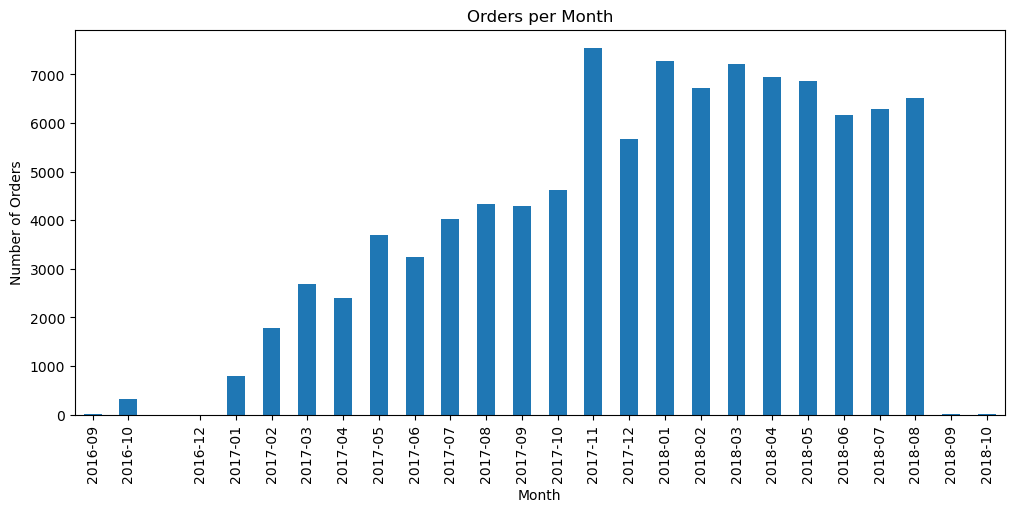

In [8]:
orders_per_month = df_orders["order_purchase_timestamp"].dt.to_period("M").value_counts().sort_index()
orders_per_month.plot(kind="bar", figsize=(12, 5))
plt.title("Orders per Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

In [16]:
order_per_customer = df_orders.groupby('customer_id')['order_id'].count()
one_time_customers = order_per_customer[order_per_customer == 1].sum()
print(f"Number of one-time customers: {one_time_customers}")

Number of one-time customers: 99441


In [17]:
orders_per_customer.value_counts().sort_index()

order_id
1    99441
Name: count, dtype: int64

In [11]:
df_customers.shape

(99441, 5)

In [12]:
df_items.shape

(112650, 7)

### Notes
- The orders dataset has 99,441 rows and 8 columns.
- `order_purchase_timestamp` was originally stored as text and has been converted to datetime.
- Missing values appear mostly in delivery-related date columns, while `order_id`, `customer_id`, and purchase timestamp have no missing values.
- Monthly order volume rises through 2017 and stays much higher during most of 2018.
- Grouping by `customer_id`, every customer appears to have exactly one order in this dataset.

In [19]:
reference_date = df_orders['order_purchase_timestamp'].max()
reference_date

Timestamp('2018-10-17 17:30:18')

In [23]:
last_order = df_orders.groupby("customer_id")["order_purchase_timestamp"].max()

last_order.head()

customer_id
00012a2ce6f8dcda20d059ce98491703   2017-11-14 16:08:26
000161a058600d5901f007fab4c27140   2017-07-16 09:40:32
0001fd6190edaaf884bcaf3d49edf079   2017-02-28 11:06:43
0002414f95344307404f0ace7a26f1d5   2017-08-16 13:09:20
000379cdec625522490c315e70c7a9fb   2018-04-02 13:42:17
Name: order_purchase_timestamp, dtype: datetime64[us]

In [22]:
inactive_customers = last_order[last_order < reference_date - pd.Timedelta(days=90)]
print(f"Number of inactive customers: {inactive_customers.shape[0]}")

Number of inactive customers: 89912
